In [1]:
"""
Convert a GPWv4 ESRI ASCII raster (.asc) to a NetCDF file.

Dependencies
------------
pip install rasterio xarray netCDF4 numpy

Fill in the input and output paths below and run:
    python convert_gpw_to_netcdf.py
"""

from pathlib import Path

import numpy as np
import rasterio
import xarray as xr
import xesmf as xe

from evt_heat_waves.config import DATA_ROOT, ERA5_PATH

In [2]:
# ============================================================================
# User inputs
# ============================================================================

POP_PATH = DATA_ROOT / 'world_pop'

INPUT_ASC = POP_PATH / "gpw_v4_population_count_rev11_2020_1_deg.asc"
OUTPUT_NC = POP_PATH / "gpw_v4_population_count_rev11_2020_1_deg.nc"

VARIABLE_NAME = "population"
LONG_NAME = "GPWv4 Population Count"
UNITS = "persons"

# Set to True if your climate model expects longitudes from 0 to 360.
CONVERT_TO_360 = True

In [3]:
# ============================================================================
# Read raster
# ============================================================================

with rasterio.open(INPUT_ASC) as src:
    data = src.read(1).astype(float)
    transform = src.transform
    nodata = src.nodata

# Replace NoData values with NaN
if nodata is not None:
    data[data == nodata] = np.nan


In [4]:
# ============================================================================
# Construct latitude and longitude coordinates
# ============================================================================

nlat, nlon = data.shape

lon = np.array([
    rasterio.transform.xy(transform, 0, j, offset="center")[0]
    for j in range(nlon)
])

lat = np.array([
    rasterio.transform.xy(transform, i, 0, offset="center")[1]
    for i in range(nlat)
])

In [5]:

# ============================================================================
# Create xarray Dataset
# ============================================================================

ds = xr.Dataset(
    data_vars={
        VARIABLE_NAME: (
            ("lat", "lon"),
            data,
            {
                "long_name": LONG_NAME,
                "units": UNITS,
            },
        )
    },
    coords={
        "lat": ("lat", lat),
        "lon": ("lon", lon),
    },
)

# Ensure latitude is increasing (-90 -> 90), which is common for climate data
ds = ds.sortby("lat")

# Optionally convert longitude from [-180, 180] to [0, 360]
if CONVERT_TO_360:
    ds = ds.assign_coords(
        lon=((ds.lon + 360) % 360)
    ).sortby("lon")


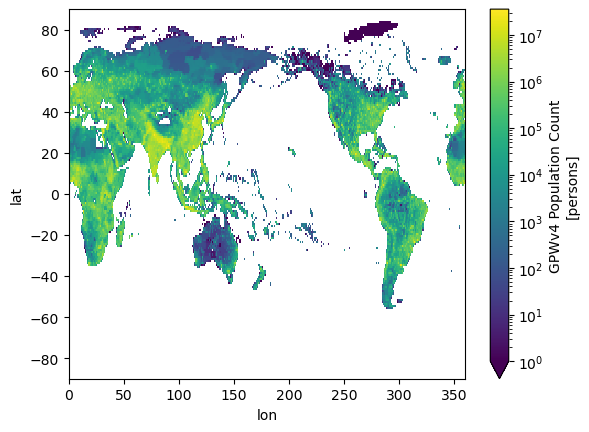

In [6]:
from matplotlib.colors import LogNorm
ds.population.plot(cmap='viridis', norm=LogNorm(vmin=1, vmax=np.nanmax(ds.population)))

In [7]:
# ============================================================================
# Add some global metadata
# ============================================================================

ds.attrs = {
    "title": "GPWv4 Population Count",
    "source": "Gridded Population of the World Version 4",
    "Conventions": "CF-1.8",
}

# ============================================================================
# Write NetCDF
# ============================================================================

encoding = {
    VARIABLE_NAME: {
        "zlib": True,
        "complevel": 4,
        "_FillValue": np.nan,
    }
}


In [8]:
# do regridding
ds_era5 = xr.open_dataset(ERA5_PATH / "era5_t2m_annual_max_1deg.nc")

regridder = xe.Regridder(
    ds,
    ds_era5[["lat", "lon"]],
    method="conservative"
)

ds_regrid = regridder(ds)
ds_regrid

/project/bbcael/ambauer/envs/gev-heat-waves/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


<xarray.Dataset>
Dimensions:     (lat: 180, lon: 360)
Coordinates:
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon         (lon) int64 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
Data variables:
    population  (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    regrid_method:  conservative

In [9]:
ds_era5

<xarray.Dataset>
Dimensions:  (lat: 180, lon: 360, year: 75)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * year     (year) int64 1950 1951 1952 1953 1954 ... 2020 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float32 ...

In [10]:
ds_regrid.to_netcdf(
    OUTPUT_NC,
    encoding=encoding,
)

print(f"Successfully wrote:\n{OUTPUT_NC}")

print("\nDataset summary:")
print(ds)

Successfully wrote:
/project/bbcael/private/bbcael/Terrestrial_heatwave/world_pop/gpw_v4_population_count_rev11_2020_1_deg.nc

Dataset summary:
<xarray.Dataset>
Dimensions:     (lat: 180, lon: 360)
Coordinates:
  * lat         (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon         (lon) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    population  (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    title:        GPWv4 Population Count
    source:       Gridded Population of the World Version 4
    Conventions:  CF-1.8
